In [ ]:
# FAZA 3 — Data understanding and preparation
#
# Analiziram atribute iz features.parquet i pripremam ih za modelovanje.
# Sve analize i odluke se donose isključivo na trening skupu, da bi se
# izbeglo curenje informacija.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
RESULTS.mkdir(exist_ok=True)

FEATURES = PROC / "features.parquet"
SEED = 7

In [ ]:
# --- 1. Učitavanje i filtriranje na trening skup ---
# Validacija i test se ne učitavaju u ovoj fazi
vremenski_prozori = pd.read_parquet(FEATURES)

train = vremenski_prozori[vremenski_prozori["split"] == "train"].reset_index(drop=True)
print("Ukupno redova u features.parquet:", len(vremenski_prozori))
print("Redova u trening skupu:", len(train))
print("Pozitivnih u treningu:", train["is_attack"].sum())

# Kolone koje nisu atributi
NON_FEATURE_COLUMNS = [
    "entity",
    "window_id",
    "day",
    "split",
    "is_attack",
    "t_min",
    "t_max",
]
atributi = [c for c in train.columns if c not in NON_FEATURE_COLUMNS]
print("\nBroj kandidata za atribute:", len(atributi))

Ukupno redova u features.parquet: 224180
Redova u trening skupu: 45685
Pozitivnih u treningu: 101

Broj kandidata za atribute: 52


In [ ]:
# --- 2. Tipovi i osnovne statistike ---
print(train[atributi].dtypes.value_counts())
print()
print(train[atributi].describe().T)

# Svi bazni atributi imaju 45.685 popunjenih vrednosti (ceo trening skup, bez NaN).
# n_failure ima mean=0.101, std=2.569, max=450 - redak, ali realan signal
# (75. percentil je i dalje 0, pa je raspodela izrazito desno zakrivljena
# kao i kod ostalih brojačkih atributa).
# Raspodele su izrazito desno zakrivljene (mean > medijana, std > mean)

float64    39
int64      13
Name: count, dtype: int64

                       count         mean          std           min  \
n_events             45685.0    57.145890   229.794030      1.000000   
n_success            45685.0    57.045245   229.770537      0.000000   
n_failure            45685.0     0.100646     2.569357      0.000000   
n_dst_comp           45685.0     5.622655    11.007889      1.000000   
n_src_comp           45685.0     5.717850    10.824797      1.000000   
n_ntlm               45685.0     3.411973    49.431076      0.000000   
n_kerberos           45685.0    16.121572    69.808877      0.000000   
n_auth_unknown       45685.0    36.213462   141.764778      0.000000   
n_auth_types         45685.0     2.318288     0.740920      1.000000   
n_logon_types        45685.0     1.814206     0.820228      1.000000   
n_domain_acct        45685.0    57.135909   229.796361      0.000000   
fail_ratio           45685.0     0.003397     0.045629      0.000000   
ntlm_rati

In [ ]:
# --- 3. Nedostajuće vrednosti ---
# NaN vrednosti su očekivane kod istorijskih (lag) atributa. Za prve prozore
# svakog entiteta istorija još ne postoji.
nan_counts = train[atributi].isna().sum()
nan_pct = (nan_counts / len(train) * 100).round(2)
nan_report = pd.DataFrame({"broj_nan": nan_counts, "procenat": nan_pct})
nan_report = nan_report[nan_report["broj_nan"] > 0].sort_values(
    "procenat", ascending=False
)
print("Atributi sa nedostajućim vrednostima:")
print(nan_report)

# Provera da NaN postoji SAMO kod istorijskih atributa (lag/ma24/sd24/z/delta)
istorijski_sufiksi = ("_lag1", "_ma24", "_sd24", "_z", "_delta")
neocekivani_nan = [c for c in nan_report.index if not c.endswith(istorijski_sufiksi)]
print(
    "\nAtributi sa NaN koji NISU istorijski (neočekivano, proveriti):", neocekivani_nan
)
# Bazni atributi nemaju nijedan NaN.
# Lag1 i Delta imaju tačno 358 NaN (0.78%), što odgovara prvom prozoru za svaki od
# 358 entiteta (nedostatak istorije). Ma24 i Sd24 imaju 691 NaN (1.51%) - više nego lag1,
# jer rolling (min_periods=2) traži dve validne vrednosti u prozoru, a pomerena serija
# već ima jedan NaN na startu. Zato su prazna prva dva prozora svakog entiteta, ne samo prvi.
# n_failure_z ima 64.34% NaN (29.392 od 45.685) - najviši procenat NaN među
# svim atributima, čak i viši od n_ntlm_z (57.59%). Standardna devijacija
# (sd24) je kod većine entiteta i dalje nula unutar kliznog prozora od 24
# prozora, jer je neuspešna prijava redak događaj. Kad god je sd24=0,
# z-skor je nedefinisan (deljenje nulom), pa ostaje NaN.
# n_events_z (1.62%) blizu osnovnih 1.51%, sd24=0 redak slučaj, broj događaja
# retko potpuno konstantan.
# n_dst/src_comp_z (3.30%/3.81%) nešto veći - povremeni mirni periodi.
# n_ntlm_z upadljivo visok (57.59%) - kod većine entiteta NTLM
# aktivnost je kroz istoriju potpuno konstantna (najverovatnije nula), što znači
# da je NTLM redak signal - kad se ipak pojavi, verovatno je informativniji baš
# zato što odudara od dugotrajne stabilnosti.
# Ovi NaN se ne tretiraju kao greška već predstavljaju strukturnu osobinu izvedenih atributa.

Atributi sa nedostajućim vrednostima:
                  broj_nan  procenat
n_failure_z          29392     64.34
n_ntlm_z             26311     57.59
n_src_comp_z          1741      3.81
n_dst_comp_z          1509      3.30
n_events_z             739      1.62
n_dst_comp_ma24        691      1.51
n_dst_comp_sd24        691      1.51
n_events_sd24          691      1.51
n_events_ma24          691      1.51
n_ntlm_sd24            691      1.51
n_ntlm_ma24            691      1.51
n_failure_ma24         691      1.51
n_src_comp_sd24        691      1.51
n_failure_sd24         691      1.51
n_src_comp_ma24        691      1.51
n_events_lag1          358      0.78
n_events_delta         358      0.78
n_dst_comp_lag1        358      0.78
n_src_comp_delta       358      0.78
n_src_comp_lag1        358      0.78
n_dst_comp_delta       358      0.78
n_failure_lag1         358      0.78
n_failure_delta        358      0.78
n_ntlm_lag1            358      0.78
n_ntlm_delta           358      0.78


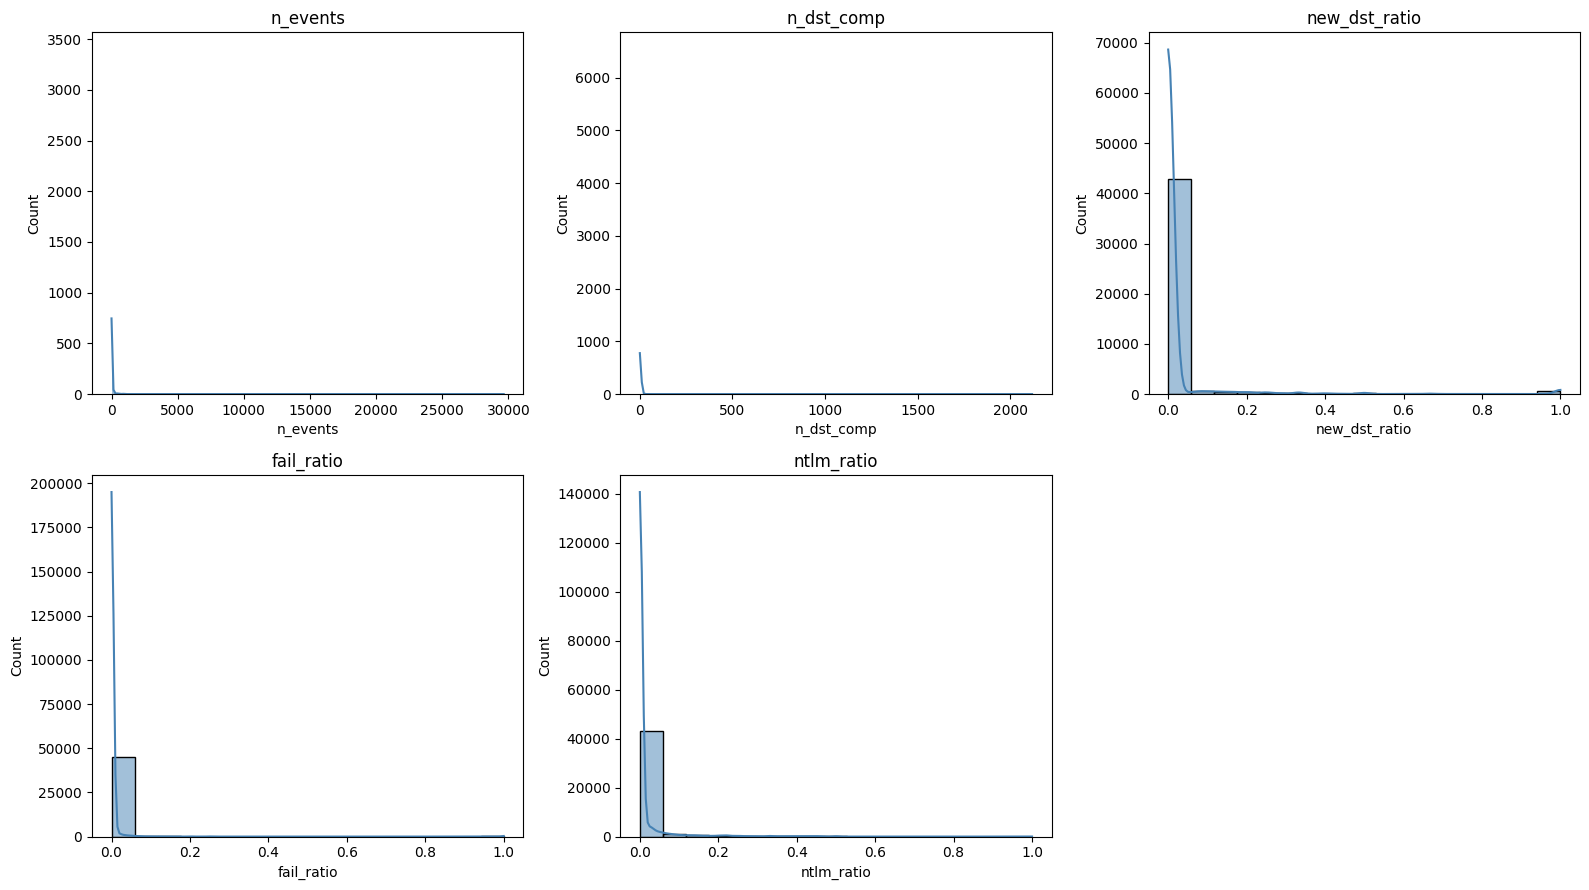

Grafik sačuvan: results/distribucije_atributa.png


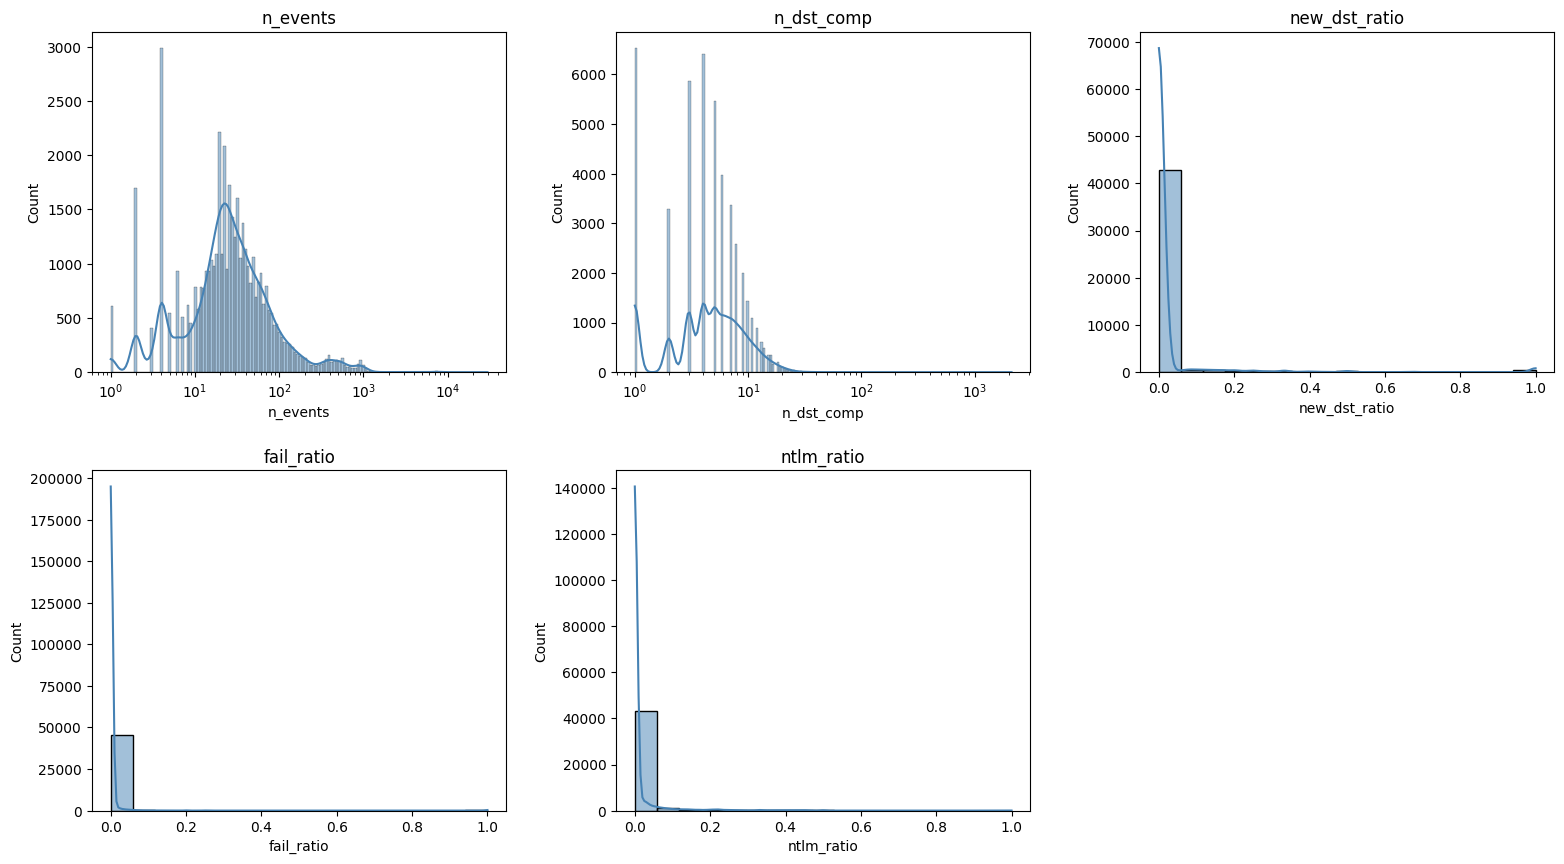

Grafik sačuvan: results/distribucije_atributa_log.png


In [ ]:
# --- 4. Raspodele ključnih atributa (linearna i log skala) ---
kljucni = ["n_events", "n_dst_comp", "new_dst_ratio", "fail_ratio", "ntlm_ratio"]

# Linearna skala
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, kljucni):
    sns.histplot(train[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(RESULTS / "distribucije_atributa.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/distribucije_atributa.png")

# Log skala za n_events i n_dst_comp
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, kljucni):
    if train[col].nunique() <= 1:
        ax.text(
            0.5, 0.5, f"{col}\n(konstanta, bez varijacije)", ha="center", va="center"
        )
        ax.set_xticks([])
        ax.set_yticks([])
    elif col in ("n_events", "n_dst_comp"):
        sns.histplot(
            train[col].dropna(), kde=True, ax=ax, color="steelblue", log_scale=True
        )
    else:
        sns.histplot(train[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout(pad=2.0)
plt.savefig(RESULTS / "distribucije_atributa_log.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/distribucije_atributa_log.png")

# n_events i n_dst_comp: na linearnoj skali se ne vidi jasno opadajući rep,
# dok je na log-skali rep jasno vidljiv i pokazuje da postoji mali broj entiteta
# sa izuzetno velikim brojem događaja ili odredišta. Ova osobina može biti značajna
# za detekciju anomalija.
# fail_ratio: Dominantna masa jena 0.0 (kao i kod ntlm_ratio), ali postoji realan rep
# prema većim vrednostima.
# ntlm_ratio: dominantno na 0.0
# new_dst_ratio: koncentrisan blizu 0, sa malom (ne ravnopravnom) bimodalnošću ka 1.0.

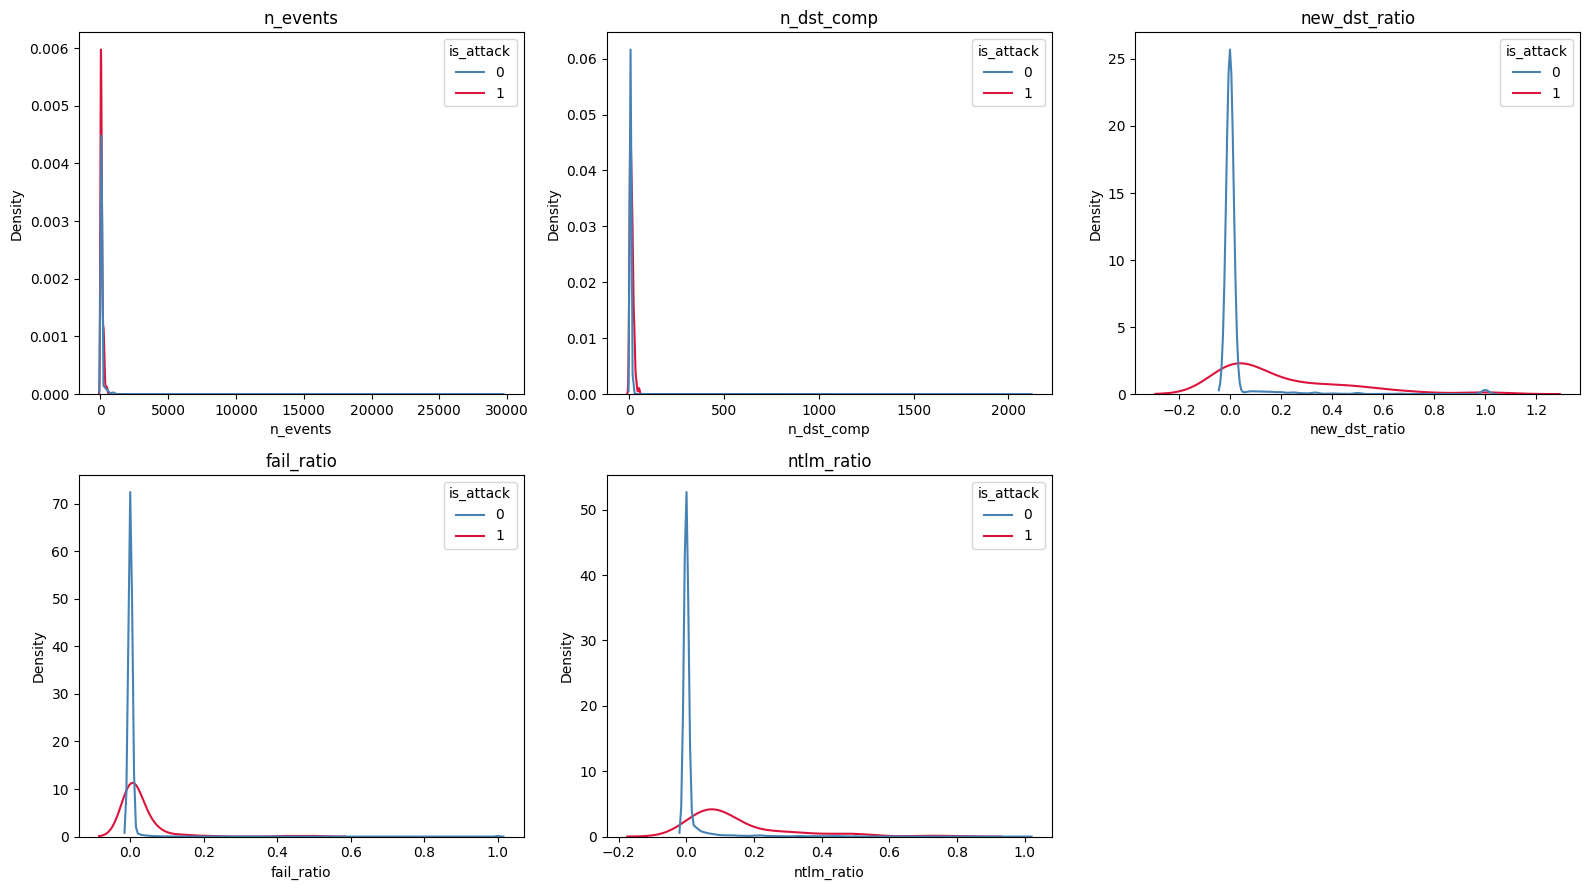

Grafik sačuvan: results/distribucije_napad_vs_normalno.png


In [ ]:
# --- 5. Poređenje raspodela: napadi naspram normalnih prozora ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, kljucni):
    sns.kdeplot(
        data=train,
        x=col,
        hue="is_attack",
        common_norm=False,
        ax=ax,
        palette={0: "steelblue", 1: "crimson"},
    )
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(RESULTS / "distribucije_napad_vs_normalno.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/distribucije_napad_vs_normalno.png")

# Poređenje raspodela napad (1) naspram normalno (0):
# new_dst_ratio i ntlm_ratio: jasno vidljiva razlika. Normalno ponašanje (plavo)
# ima oštar, uzak vrh uz 0.0 (većina prozora ima malo novih odredišta i
# malo NTLM saobraćaja). Napad (crveno) je mnogo ravniji i rasprostranjen preko
# celog opsega, sa vidljivim delom i na višim vrednostima.
# n_events i n_dst_comp: na ovoj (linearnoj) skali obe krive su zbijene uz nulu
# i vizuelna razlika između klasa nije jasno vidljiva.
# fail_ratio: Prosečna vrednost je vidljivo viša kod napadačkih prozora (0.0205)
# nego kod normalnih (0.0049), četvorostruka razlika, u skladu sa očekivanjem da
# neuspešne prijave prate pokušaje pristupa sa pogrešnim kredencijalima tokom lateralnog kretanja.

In [ ]:
# --- 6. Analiza autlajera ---
# Autlajeri se ovde ne winsorizuju, ne uklanjaju niti imputiraju. Ekstremne
# vrednosti (nagli skok broja odredišta, visok z-skor) su često sam signal
# napada, a ne šum. Intervencija bi mogla da izbriše upravo ciljni signal.
# Intervencija sledi jedino ako se nađe fizički nemoguća vrednost
# (npr. negativan broj događaja).


def analyze_outliers(df, cols):
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        p01, p99 = df[col].quantile([0.01, 0.99])

        out_iqr = ((df[col] < lower_iqr) | (df[col] > upper_iqr)).sum()
        out_pct = ((df[col] < p01) | (df[col] > p99)).sum()

        print(f"--- {col} ---")
        print(
            f"IQR granice: [{lower_iqr:.2f}, {upper_iqr:.2f}] -> {out_iqr} ({out_iqr / len(df) * 100:.2f}%)"
        )
        print(
            f"Percentil granice (1/99): [{p01:.2f}, {p99:.2f}] -> {out_pct} ({out_pct / len(df) * 100:.2f}%)"
        )


analyze_outliers(train, ["n_events", "n_dst_comp", "new_dst_ratio"])

# Provera fizički nemogućih vrednosti
nenegativni = ["n_events", "n_success", "n_failure", "n_dst_comp", "n_src_comp"]
nemoguce = {c: int((train[c] < 0).sum()) for c in nenegativni}
print("\nBroj fizički nemogućih (negativnih) vrednosti po koloni:", nemoguce)

# Autlajeri, IQR naspram percentila:
# Kod IQR metode za new_dst_ratio Q1=Q3=0, pa svaka nenulta vrednost
# lažno upada u "autlajer"), dok percentil metoda daje realniju procenu. U svakom slučaju ova provera je samo informativna.
# Nema fizički nemogućih (negativnih) vrednosti ni u jednoj koloni.

--- n_events ---
IQR granice: [-38.00, 98.00] -> 4356 (9.53%)
Percentil granice (1/99): [1.00, 668.32] -> 457 (1.00%)
--- n_dst_comp ---
IQR granice: [-3.00, 13.00] -> 2140 (4.68%)
Percentil granice (1/99): [1.00, 20.00] -> 360 (0.79%)
--- new_dst_ratio ---
IQR granice: [0.00, 0.00] -> 2958 (6.47%)
Percentil granice (1/99): [0.00, 1.00] -> 0 (0.00%)

Broj fizički nemogućih (negativnih) vrednosti po koloni: {'n_events': 0, 'n_success': 0, 'n_failure': 0, 'n_dst_comp': 0, 'n_src_comp': 0}


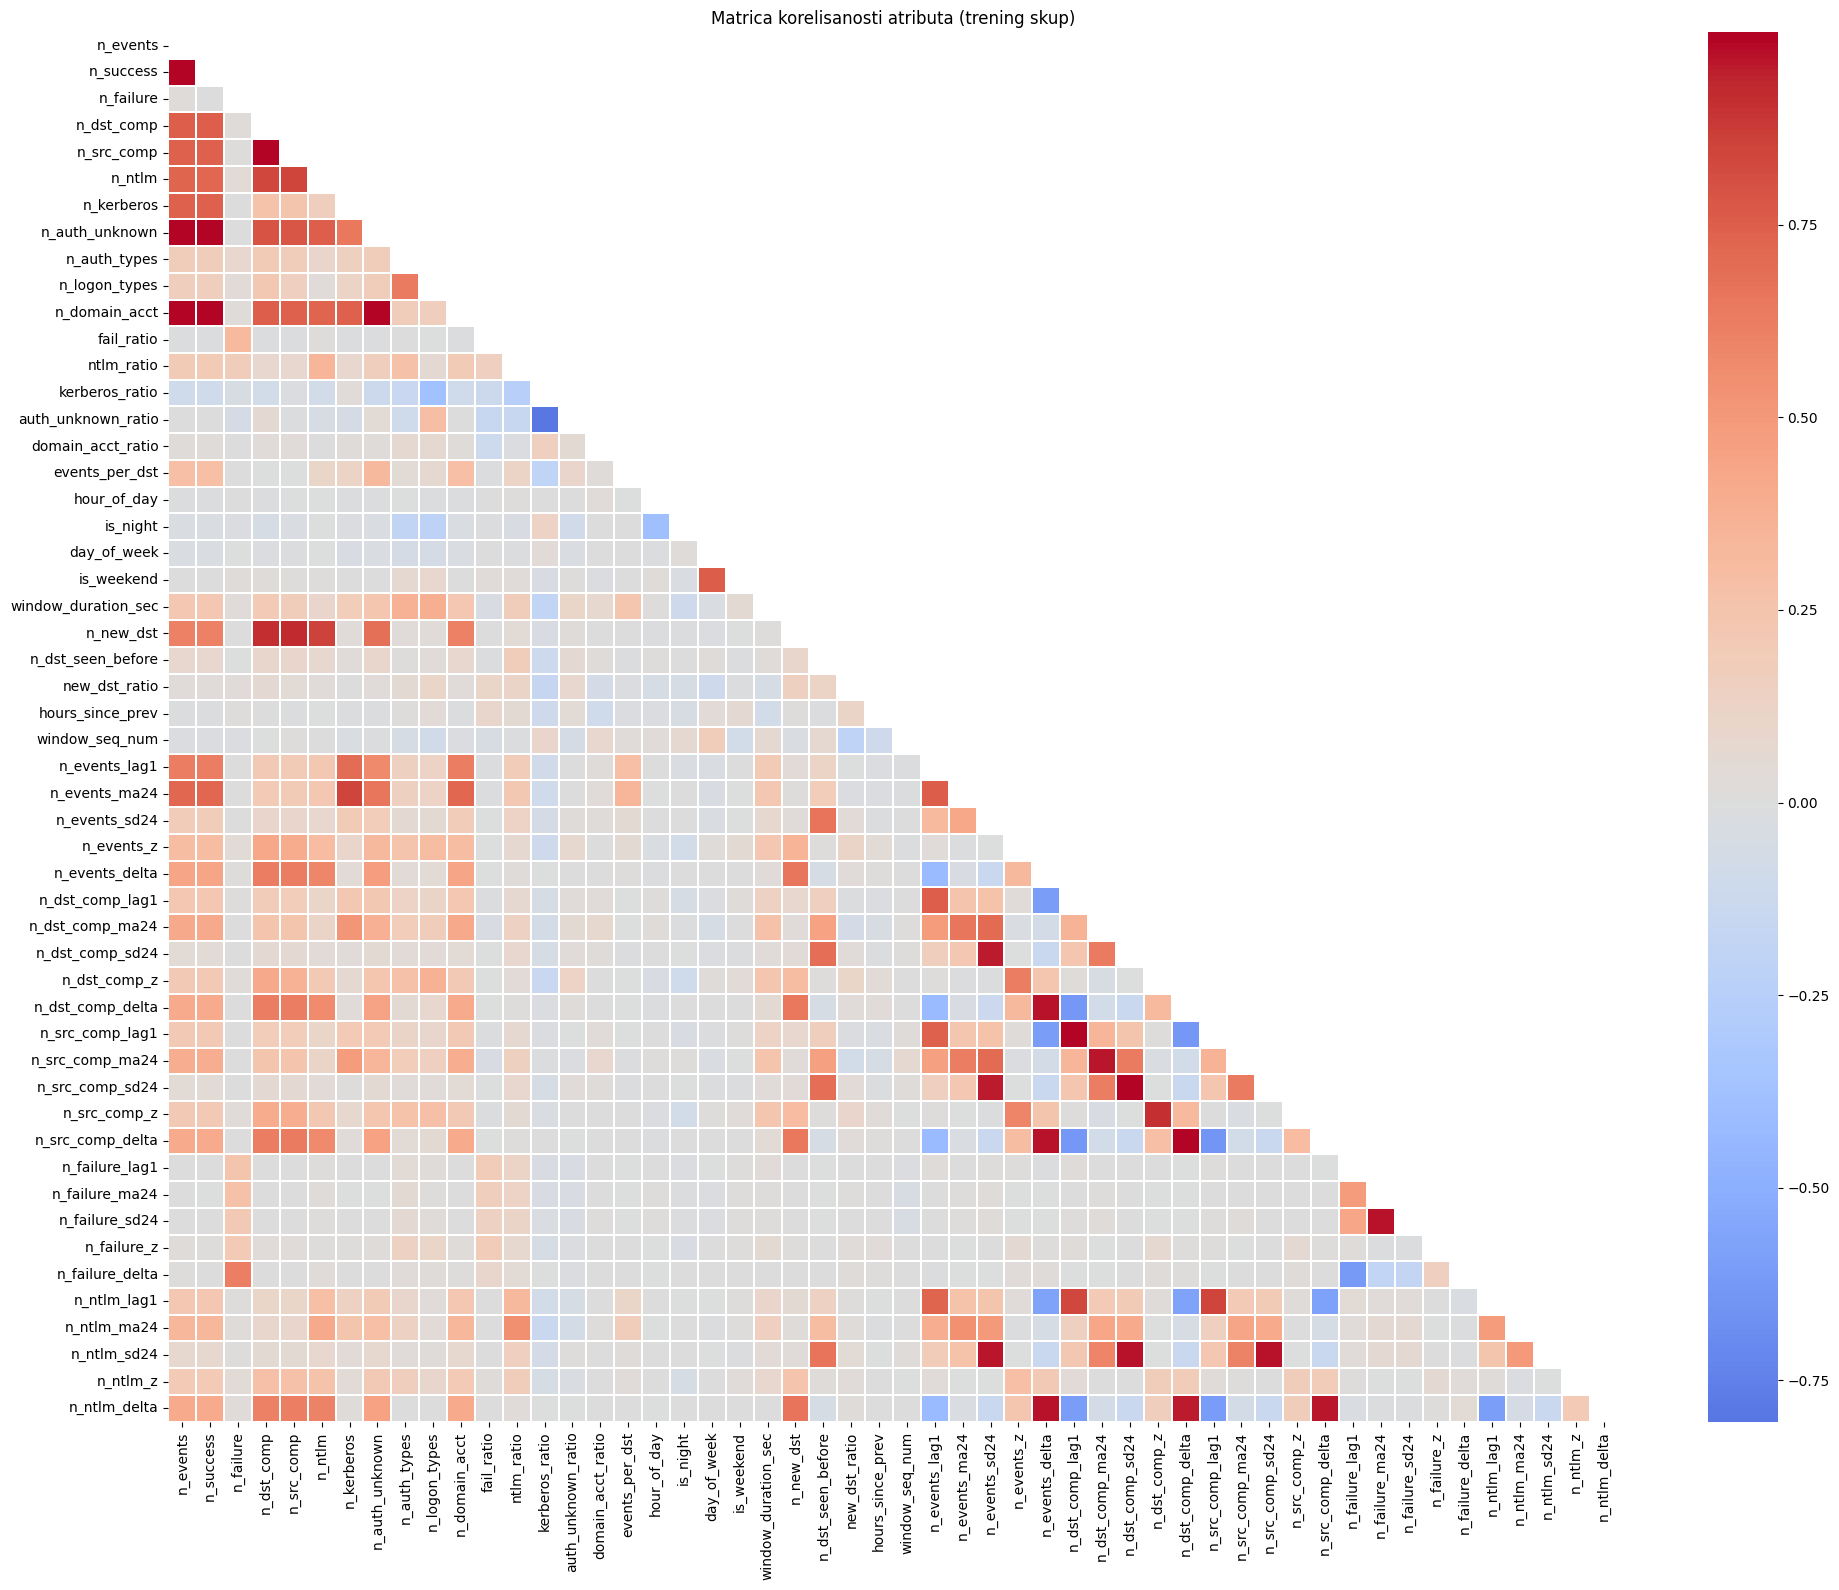

Grafik sačuvan: results/matrica_korelacije.png

Parovi atributa sa korelacijom >= 0.95:
n_domain_acct     n_events            1.000000
n_success         n_events            0.999937
n_domain_acct     n_success           0.999937
n_src_comp_sd24   n_dst_comp_sd24     0.998534
n_src_comp_delta  n_dst_comp_delta    0.991853
n_src_comp_lag1   n_dst_comp_lag1     0.987102
n_src_comp        n_dst_comp          0.987022
n_auth_unknown    n_success           0.986550
n_domain_acct     n_auth_unknown      0.986492
n_auth_unknown    n_events            0.986492
n_ntlm_delta      n_events_delta      0.971438
n_ntlm_sd24       n_src_comp_sd24     0.971097
n_src_comp_delta  n_events_delta      0.969189
n_ntlm_sd24       n_dst_comp_sd24     0.969116
n_failure_sd24    n_failure_ma24      0.968480
n_dst_comp_delta  n_events_delta      0.965497
n_ntlm_delta      n_src_comp_delta    0.964442
n_src_comp_ma24   n_dst_comp_ma24     0.963265
n_ntlm_sd24       n_events_sd24       0.958877
n_ntlm_delta      n

In [ ]:
# --- 7. Matrica korelisanosti ---
numericki = train[atributi].select_dtypes(include="number").columns.tolist()
corr_matrix = train[numericki].fillna(0).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Matrica korelisanosti atributa (trening skup)")
plt.tight_layout()
plt.savefig(RESULTS / "matrica_korelacije.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/matrica_korelacije.png")

# Parovi sa visokom korelacijom >= 0.95
corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
visoka_korelacija = upper.unstack().dropna()
visoka_korelacija = visoka_korelacija[visoka_korelacija >= 0.95].sort_values(
    ascending=False
)
print("\nParovi atributa sa korelacijom >= 0.95:")
print(visoka_korelacija)


# Uklanjaju se samo atributi koji su visoko korelisani sa drugim atributima, a ne nose dodatnu informaciju (redundantni). Odluka o tome koji od para zadržati se donosi u filter fazi ispod, na osnovu mutual information sa targetom.

In [ ]:
# --- 8. Korelacija sa target varijablom ---
print(f"Udeo pozitivnih u treningu: {train['is_attack'].mean() * 100:.3f}%")

target_corr = (
    train[numericki]
    .fillna(0)
    .corrwith(train["is_attack"])
    .abs()
    .sort_values(ascending=False)
)
print("Top 15 atributa po apsolutnoj Pearsonovoj korelaciji sa is_attack:")
print(target_corr.head(15))
# Pearsonova korelacija sa binarnim targetom koji ima 0.221% pozitivnih u
# treningu daje mikroskopske vrednosti za sve atribute - ovo je očekivano
# kod ovakvog disbalansa, nije znak da atributi nisu informativni.
# Najinformativniji atribut je ntlm_ratio (0.110), zatim sledi n_failure_z (0.096) pa onda n_auth_types (0.077).

Udeo pozitivnih u treningu: 0.221%
Top 15 atributa po apsolutnoj Pearsonovoj korelaciji sa is_attack:
ntlm_ratio           0.109987
n_failure_z          0.095567
n_auth_types         0.076648
n_ntlm_z             0.068011
new_dst_ratio        0.064398
n_src_comp_z         0.045882
n_logon_types        0.039073
n_src_comp_ma24      0.037492
kerberos_ratio       0.037458
n_dst_comp_ma24      0.036376
n_dst_comp_z         0.035219
n_dst_seen_before    0.033290
n_src_comp           0.032743
hour_of_day          0.032584
n_dst_comp           0.032563
dtype: float64


In [ ]:
# --- 9. Imputacija nedostajućih vrednosti  ---
# _delta i _z: popunjavaju se sa 0 (nema poznatog odstupanja od
# istorije je neutralna vrednost, različita od proseka).
# _lag1, _ma24, _sd24: popunjavaju se medijanom izračunatom na treningu.
# has_history: binarni indikator (1 ako entitet ima bar jedan prethodni
# prozor). Model tako zna da je vrednost imputirana, a ne stvarno izmerena.
train["has_history"] = (train["window_seq_num"] >= 1).astype(int)

delta_z_kolone = [c for c in atributi if c.endswith("_delta") or c.endswith("_z")]
ostale_istorijske = [c for c in atributi if c.endswith(("_lag1", "_ma24", "_sd24"))]

imputation_values = {}

for c in delta_z_kolone:
    imputation_values[c] = 0.0

for c in ostale_istorijske:
    imputation_values[c] = float(train[c].median())

print("Broj atributa imputiranih sa 0 (_delta, _z):", len(delta_z_kolone))
print(
    "Broj atributa imputiranih sa medijanom (_lag1, _ma24, _sd24):",
    len(ostale_istorijske),
)

train_imputed = train.copy()
for col, val in imputation_values.items():
    train_imputed[col] = train_imputed[col].fillna(val)

preostali_nan = train_imputed[atributi + ["has_history"]].isna().sum().sum()
print("Preostalih NaN posle imputacije (mora biti 0):", preostali_nan)
assert preostali_nan == 0, "Imputacija nije pokrila sve NaN vrednosti."

Broj atributa imputiranih sa 0 (_delta, _z): 10
Broj atributa imputiranih sa medijanom (_lag1, _ma24, _sd24): 15
Preostalih NaN posle imputacije (mora biti 0): 0


In [ ]:
# --- 10. Filter metoda: mutual information ---
# Mutual information (MI) meri koliko znanje o vrednosti atributa smanjuje
# neizvesnost o target varijabli. Za razliku od Pearsonove korelacije,
# hvata i nelinearne veze, pa je pouzdaniji filter kod ovakvog disbalansa.
# Izbacujem atribute bez ikakve zavisnosti sa targetom (MI = 0) kao
# i redundantne atribute iz visoko korelisanih parova.
X_train_num = train_imputed[numericki + ["has_history"]]
y_train = train_imputed["is_attack"]

mi_scores = mutual_info_classif(X_train_num, y_train, random_state=SEED)
mi_results = pd.DataFrame(
    {"Atribut": X_train_num.columns, "MI_Score": mi_scores}
).sort_values("MI_Score", ascending=False)
mi_map = mi_results.set_index("Atribut")["MI_Score"]

print("Top 20 atributa po mutual information:")
print(mi_results.head(20))

bez_zavisnosti = set(mi_map[mi_map == 0].index)
print(f"\nAtributa sa MI = 0 (izbačeno): {len(bez_zavisnosti)}")
print(sorted(bez_zavisnosti))

# Nijedan atribut nema MI=0.

preostalo_posle_mi = [c for c in X_train_num.columns if c not in bez_zavisnosti]

# Iz svakog visoko korelisanog para zadržava se onaj sa većim MI skorom.
izbaceno_zbog_korelacije = set()
for (a1, a2), korelacija in visoka_korelacija.items():
    if a1 not in preostalo_posle_mi or a2 not in preostalo_posle_mi:
        continue
    if a1 in izbaceno_zbog_korelacije or a2 in izbaceno_zbog_korelacije:
        continue
    losiji = a1 if mi_map.get(a1, 0) < mi_map.get(a2, 0) else a2
    izbaceno_zbog_korelacije.add(losiji)

atributi_posle_filtera = [
    c for c in preostalo_posle_mi if c not in izbaceno_zbog_korelacije
]

print(
    f"\nIzbačeno zbog redundantnosti (korelacija >= 0.95, manji MI): {len(izbaceno_zbog_korelacije)}"
)
print(sorted(izbaceno_zbog_korelacije))
print(
    f"\nOstalo posle filtera: {len(atributi_posle_filtera)} od {X_train_num.shape[1]} atributa"
)
# Konačna provera: da li u atributi_posle_filtera postoji preživeli par ≥0.95
provera_posle_filtera = train_imputed[atributi_posle_filtera].corr().abs()
maska_bez_duplikata = np.triu(np.ones(provera_posle_filtera.shape), k=1).astype(bool)
preostalo_visoko = provera_posle_filtera.where(maska_bez_duplikata).unstack().dropna()
preostalo_visoko = preostalo_visoko[preostalo_visoko >= 0.95]

print("Preostalih visoko korelisanih parova posle filtera:", len(preostalo_visoko))
print(preostalo_visoko)
assert len(preostalo_visoko) == 0, "Filter nije uklonio sve visoko korelisane parove."

X_posle_filtera = X_train_num[atributi_posle_filtera]

Top 20 atributa po mutual information:
              Atribut  MI_Score
52        has_history  0.009700
15  domain_acct_ratio  0.007893
8        n_auth_types  0.007315
12         ntlm_ratio  0.005244
5              n_ntlm  0.004971
51       n_ntlm_delta  0.004809
9       n_logon_types  0.004335
50           n_ntlm_z  0.003857
19        day_of_week  0.003655
4          n_src_comp  0.003103
24      new_dst_ratio  0.002633
18           is_night  0.002488
3          n_dst_comp  0.002397
22          n_new_dst  0.002352
23  n_dst_seen_before  0.002119
46    n_failure_delta  0.002021
2           n_failure  0.001999
45        n_failure_z  0.001910
39    n_src_comp_sd24  0.001867
11         fail_ratio  0.001785

Atributa sa MI = 0 (izbačeno): 0
[]

Izbačeno zbog redundantnosti (korelacija >= 0.95, manji MI): 13
['n_auth_unknown', 'n_domain_acct', 'n_dst_comp', 'n_dst_comp_delta', 'n_dst_comp_lag1', 'n_dst_comp_sd24', 'n_events_delta', 'n_events_sd24', 'n_failure_ma24', 'n_ntlm_sd24', 'n_src_comp

Dijagnostika 1: TimeSeriesSplit(n_splits=5)
Veličina poduzorka za RFECV: 15229
Pozitivnih u celom poduzorku: 40
Fold 1: trening=2539 (pozitivnih=4), test=2538 (pozitivnih=0)
Fold 2: trening=5077 (pozitivnih=4), test=2538 (pozitivnih=2)
Fold 3: trening=7615 (pozitivnih=6), test=2538 (pozitivnih=2)
Fold 4: trening=10153 (pozitivnih=8), test=2538 (pozitivnih=32)
Fold 5: trening=12691 (pozitivnih=40), test=2538 (pozitivnih=0)

Dijagnostika 2: TimeSeriesSplit(n_splits=3)
Fold 1: trening=3808 (pozitivnih=4), test=3807 (pozitivnih=2)
Fold 2: trening=7615 (pozitivnih=6), test=3807 (pozitivnih=22)
Fold 3: trening=11422 (pozitivnih=28), test=3807 (pozitivnih=12)

Wrapper (RFECV + Random Forest) je izabrao 15 od 40 atributa:
['day_of_week', 'events_per_dst', 'hour_of_day', 'kerberos_ratio', 'n_dst_seen_before', 'n_events_ma24', 'n_ntlm', 'n_ntlm_delta', 'n_ntlm_lag1', 'n_ntlm_ma24', 'n_ntlm_z', 'n_src_comp_sd24', 'new_dst_ratio', 'ntlm_ratio', 'window_seq_num']


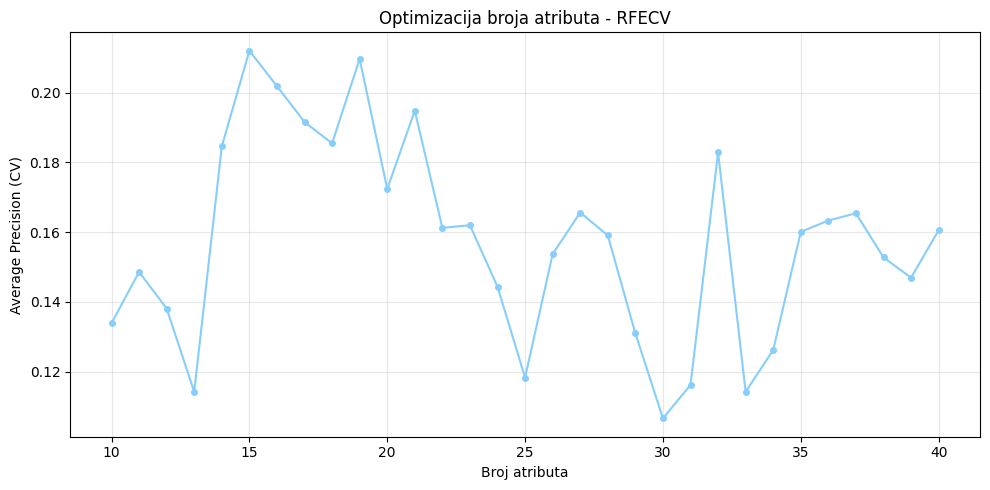

Grafik sačuvan: results/rfecv_optimizacija.png


In [ ]:
# --- 11. Wrapper metoda: RFECV (Random Forest) sa TimeSeriesSplit, na atributima posle filtera ---
# Podaci su vremenski uređeni. Obična unakrsna validacija bi mešala prošlost
# i budućnost unutar samog treninga što bi dovelo do curenja podataka.
# TimeSeriesSplit deli podatke na uzastopne vremenske blokove.

# RFECV je spor - radi se na poduzorku ako je trening velik.
RFECV_SAMPLE_SIZE = 15_000
if len(train_imputed) > RFECV_SAMPLE_SIZE:
    sample_idx = train_imputed.sort_values("window_id").index
    korak = len(sample_idx) // RFECV_SAMPLE_SIZE
    sample_idx = sample_idx[:: max(korak, 1)]
    X_rfecv = X_posle_filtera.loc[sample_idx]
    y_rfecv = y_train.loc[sample_idx]
else:
    X_rfecv, y_rfecv = X_posle_filtera, y_train

# Dijagnostika: broj pozitivnih primera po foldu, n_splits=5 (početni pokušaj).
# Proverava da li n_splits=5 daje foldove sa premalo (ili nula) pozitivnih
# primera u testu, što bi činilo unakrsnu validaciju nepouzdanom.
print("Dijagnostika 1: TimeSeriesSplit(n_splits=5)")
print("Veličina poduzorka za RFECV:", len(X_rfecv))
print("Pozitivnih u celom poduzorku:", int(y_rfecv.sum()))

tscv_dijagnoza = TimeSeriesSplit(n_splits=5)
for i, (train_idx, test_idx) in enumerate(tscv_dijagnoza.split(X_rfecv), start=1):
    y_tr, y_te = y_rfecv.iloc[train_idx], y_rfecv.iloc[test_idx]
    print(
        f"Fold {i}: trening={len(train_idx)} (pozitivnih={int(y_tr.sum())}), "
        f"test={len(test_idx)} (pozitivnih={int(y_te.sum())})"
    )

print()

# Dijagnostika: da li n_splits=3 popravlja raspodelu pozitivnih po foldu
print("Dijagnostika 2: TimeSeriesSplit(n_splits=3)")

tscv_probno = TimeSeriesSplit(n_splits=3)
for i, (train_idx, test_idx) in enumerate(tscv_probno.split(X_rfecv), start=1):
    y_tr, y_te = y_rfecv.iloc[train_idx], y_rfecv.iloc[test_idx]
    print(
        f"Fold {i}: trening={len(train_idx)} (pozitivnih={int(y_tr.sum())}), "
        f"test={len(test_idx)} (pozitivnih={int(y_te.sum())})"
    )

print()

# Stvarni RFECV, sa n_splits=3 na osnovu gornje dijagnostike
tscv = TimeSeriesSplit(n_splits=3)
rfecv = RFECV(
    estimator=RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=SEED
    ),
    cv=tscv,
    scoring="average_precision",
    min_features_to_select=10,
    n_jobs=-1,
)
rfecv.fit(X_rfecv, y_rfecv)

wrapper_odabrani = set(X_posle_filtera.columns[rfecv.support_])
print(
    f"Wrapper (RFECV + Random Forest) je izabrao {len(wrapper_odabrani)} od "
    f"{X_posle_filtera.shape[1]} atributa:"
)
print(sorted(wrapper_odabrani))


# Prikaz odabranih atributa.
plt.figure(figsize=(10, 5))
plt.plot(
    range(10, len(rfecv.cv_results_["mean_test_score"]) + 10),
    rfecv.cv_results_["mean_test_score"],
    color="lightskyblue",
    marker="o",
    markersize=4,
)
plt.xlabel("Broj atributa")
plt.ylabel("Average Precision (CV)")
plt.title("Optimizacija broja atributa - RFECV")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "rfecv_optimizacija.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/rfecv_optimizacija.png")


# RFECV je odabrao 15 kao dovoljan broj, ne nužno apsolutni maksimum pojedinačne tačke na grafiku.

In [ ]:
# --- 12. Embedded metoda: značaj atributa iz XGBoost, na atributima posle filtera ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="aucpr",
    n_jobs=-1,
)
xgb_model.fit(X_posle_filtera, y_train)
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=X_posle_filtera.columns
)
xgb_importance = xgb_importance.sort_values(ascending=False)

print("Top 20 atributa po XGBoost značaju:")
print(xgb_importance.head(20))

# Za razliku od wrapper metode (RFECV), koja sama određuje optimalan broj atributa kroz unakrsnu validaciju, embedded metod samo rangira koji su najznačajniji atributi.

# Proveravam da li je pad postepen između 15. i 20. atributa
pad_15_do_20 = xgb_importance.iloc[14] - xgb_importance.iloc[19]
print(f"\nRazlika značaja između 15. i 20. atributa: {pad_15_do_20:.5f}")

EMBEDDED_TOP_N = 20
embedded_odabrani = set(xgb_importance.head(EMBEDDED_TOP_N).index)
print(f"\nEmbedded (XGBoost, top {EMBEDDED_TOP_N}) je izabrao:")
print(sorted(embedded_odabrani))

Top 20 atributa po XGBoost značaju:
ntlm_ratio            0.585354
n_dst_seen_before     0.056327
hour_of_day           0.045010
day_of_week           0.040231
n_failure_lag1        0.039421
new_dst_ratio         0.024084
events_per_dst        0.022778
window_seq_num        0.022326
n_src_comp            0.020355
n_ntlm_ma24           0.017681
n_ntlm_z              0.011520
n_failure             0.010349
n_failure_sd24        0.009797
n_ntlm_delta          0.008551
n_dst_comp_ma24       0.008043
n_events_lag1         0.007867
n_ntlm                0.007549
domain_acct_ratio     0.006877
n_src_comp_z          0.006679
auth_unknown_ratio    0.005963
dtype: float32

Razlika značaja između 15. i 20. atributa: 0.00208

Embedded (XGBoost, top 20) je izabrao:
['auth_unknown_ratio', 'day_of_week', 'domain_acct_ratio', 'events_per_dst', 'hour_of_day', 'n_dst_comp_ma24', 'n_dst_seen_before', 'n_events_lag1', 'n_failure', 'n_failure_lag1', 'n_failure_sd24', 'n_ntlm', 'n_ntlm_delta', 'n_ntlm_ma24'

In [ ]:
# --- 13. Finalna odluka: presek  wrapper i embedded selekcije ---
# Zadržavaju se samo atributi koje su i wrapper (RFECV+RF) i embedded
# (XGBoost) nezavisno potvrdili kao bitne.
finalna_lista = sorted(wrapper_odabrani & embedded_odabrani)

print(f"Finalno izabrano (presek wrapper i embedded): {len(finalna_lista)} atributa")
print(finalna_lista)

print(f"\nSamo u wrapper-u: {sorted(wrapper_odabrani - embedded_odabrani)}")
print(f"Samo u embedded-u: {sorted(embedded_odabrani - wrapper_odabrani)}")

# Tri nivoa skupa atributa, radi transparentnosti u radu:
print("\nPregled po fazama selekcije:")
print(f"Pun skup:               {X_train_num.shape[1]}")
print(f"Posle filtera:          {len(atributi_posle_filtera)}")
print(f"Posle wrapper+embedded: {len(finalna_lista)}")

# Finalna selekcija atributa je izraženo koncentrisana oko NTLM signala (5 od 11 atributa), što se poklapa sa teorijskim očekivanjem da je NTLM ključan indikator Pass-the-Hash tehnika, ali istovremeno ukazuje na mogući rizik generalizacije. Model bi mogao biti manje efikasan protiv napada koji izbegavaju NTLM protokol.

Finalno izabrano (presek wrapper i embedded): 11 atributa
['day_of_week', 'events_per_dst', 'hour_of_day', 'n_dst_seen_before', 'n_ntlm', 'n_ntlm_delta', 'n_ntlm_ma24', 'n_ntlm_z', 'new_dst_ratio', 'ntlm_ratio', 'window_seq_num']

Samo u wrapper-u: ['kerberos_ratio', 'n_events_ma24', 'n_ntlm_lag1', 'n_src_comp_sd24']
Samo u embedded-u: ['auth_unknown_ratio', 'domain_acct_ratio', 'n_dst_comp_ma24', 'n_events_lag1', 'n_failure', 'n_failure_lag1', 'n_failure_sd24', 'n_src_comp', 'n_src_comp_z']

Pregled po fazama selekcije:
Pun skup:               53
Posle filtera:          40
Posle wrapper+embedded: 11


In [ ]:
# --- 14. Čuvanje rezultata ---
with open(PROC / "features_full.json", "w", encoding="utf-8") as f:
    json.dump(list(X_train_num.columns), f, ensure_ascii=False, indent=2)

with open(PROC / "selected_features.json", "w", encoding="utf-8") as f:
    json.dump(finalna_lista, f, ensure_ascii=False, indent=2)

with open(PROC / "features_after_filter.json", "w", encoding="utf-8") as f:
    json.dump(atributi_posle_filtera, f, ensure_ascii=False, indent=2)

with open(PROC / "imputation_values.json", "w", encoding="utf-8") as f:
    json.dump(imputation_values, f, ensure_ascii=False, indent=2)

print("Sačuvano: data/processed/features_full.json (pun skup, pre filtera)")
print(
    "Sačuvano: data/processed/features_after_filter.json (posle filtera, pre wrapper/embedded)"
)
print(
    "Sačuvano: data/processed/selected_features.json (finalni, presek wrapper+embedded)"
)
print("Sačuvano: data/processed/imputation_values.json")

Sačuvano: data/processed/features_full.json (pun skup, pre filtera)
Sačuvano: data/processed/features_after_filter.json (posle filtera, pre wrapper/embedded)
Sačuvano: data/processed/selected_features.json (finalni, presek wrapper+embedded)
Sačuvano: data/processed/imputation_values.json
